
# Project Milestone One: Forming Your Team, Understanding the Problem, and Exploring the Data

#### **Due:** Midnight on March 29th (with 2-hour grace period) — **worth 25 points**

> **Note:** Because we must begin manual grading immediately, there will be *no* late period for this milestone. 

This milestone is the first phase of your project. You’ll begin working in teams, select your dataset, perform basic exploratory data analysis (EDA), and frame your classification problem.  

1. **Form your project team.**  
   Convene your team and complete the **Team Contract** (available in your Homework Repository). This is **due on Sunday, March 22nd** at midnight (along with Homework 07). Each member must review and sign it before submission.

2. **Select a team leader.**  
   Choose one team member to act as the **Gradescope submitter** for your team. The entire team should collaborate on the notebook, but only the leader will submit.

3. **Explore your dataset and frame your task.**  
   You’ll work through the notebook to  
   - Examine both provided datasets,  
   - Choose one for your project,
   - Be able to describe the classification problem you’ll be solving in business or applied terms, 
   - Conduct basic EDA to understand its structure and challenges, and
   - Spot potential challenges, propose solutions, and select appropriate performance metrics.  

This milestone focuses on understanding your data and clearly articulating what your model will eventually predict. You are not required to build a model yet (that will happen in Milestone 2) but of course you have lots of example models to choose from previous Homeworks and Coding Notebooks and you may wish to explore a baseline model as you do this first phase of your project. 


### The Datasets

The final project is a **classification task** using **one of two datasets**—one image-based and one text-based. These are the two
domains we have studied in detail, after learning the fundamentals in the first three weeks, and you have all you need to approach either of these datasets with confidence. 

#### **1. Food-101 (Images)**  
A web-scraped collection of approximately **101,000 color photos** across **101 food categories** (≈ 800 train / 100 validation / 100 test per class).  
Images vary widely in **lighting, composition, and color balance**, making this dataset excellent for practicing **data cleaning**, **EDA**, and **augmentation** techniques such as random crops, flips, and color jitter. 

#### **2. HuffPost News Category (Text)**  
Roughly **200,000 short news items** labeled into **41 topical categories** (e.g., *POLITICS*, *ENTERTAINMENT*, *PARENTING*).  
Each record contains a **headline**, a **short description**, which we will concatenate with a separator token to make a single text string: 
> `"headline [SEP] short_description"`.
> 
The `[SEP]` token simply marks where the headline ends and the description begins—mirroring conventions used in transformer models such as BERT.


### What To Do


We’ve provided template code to start your project:

* **Download** your selected dataset.
* **Visualize** a few representative samples (images or text excerpts).

After reviewing both datasets, you’ll **choose one** for your semester project.

In the sections that follow:

* **Problem One — Exploratory Data Analysis (EDA):**
  Quantify scale and structure, check class balance, and note any missing/duplicate or inconsistent entries.

* **Problem Two — Challenges & Solution Paths:**
  Identify likely issues (e.g., overlapping categories, imbalanced labels, data-quality problems, length/size variance) and outline practical remedies you would try. *(No model training required.)*

For tips on working with **Hugging Face Datasets** (helpful for large datasets), see the **Appendix**.

> **Important:** Keep only the section for the dataset you select and delete the other before submitting **Milestone 1**.


In [6]:
# ============================================
# Useful Imports
# ============================================

# --- Standard Libraries
import os
import time
import math
import random
from collections import Counter

# --- Core Data / Numerics
import numpy as np
import pandas as pd

# --- Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker  # optional (for formatted axes)

# --- Notebook Display
try:
    from IPython.display import display
except ImportError:
    def display(x):
        print(x)

# --- Optional packages used later in the notebook / appendix
try:
    import tensorflow as tf
except Exception:
    tf = None

try:
    from tqdm import tqdm
except Exception:
    def tqdm(x, *args, **kwargs):
        return x

# spaCy is only used in the appendix / optional preprocessing cells.
# Keep it out of the startup path so Problems 1-2 can run even if spaCy is unavailable.
spacy = None

# --- (Optional) Classical ML Baseline Tools
# from sklearn.pipeline import Pipeline
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score


# ============================================
# Global Configuration & Small Utilities
# ============================================

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
if tf is not None:
    tf.keras.utils.set_random_seed(random_seed)  # sets Python, NumPy, and TensorFlow seeds

# Utility: format seconds as HH:MM:SS

"""
Example usage to time your code:

start_time = time.time()
# ... your code here ...
print("Execution Time:", format_hms(time.time() - start_time))
"""

def format_hms(seconds: float) -> str:
    """Convert seconds to HH:MM:SS format."""
    return time.strftime("%H:%M:%S", time.gmtime(seconds))


In [7]:
# If needed (in a new env):
# !pip install -U pandas matplotlib datasets pillow tqdm ipython

In [8]:
# --- Hugging Face Datasets
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("datasets") is None:
    print("Installing the Hugging Face 'datasets' package...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "datasets"])

from datasets import load_dataset, DatasetDict
from datasets.features import ClassLabel


Installing the Hugging Face 'datasets' package...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 526.8/526.8 kB 12.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 618.0/618.0 kB 25.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 70.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 89.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [datasets]/17 [datasets]ce-hub]


## Prelude: Chosen Dataset

This submission keeps only the **HuffPost News Category** path so the notebook runs directly into the text-dataset workflow.
The original Food-101 starter section was intentionally disabled because it is not used in this project and can take a long time to download.

Run the HuffPost cells below, then continue to Problem 1 and Problem 2.


---

### Food-101 Section Removed

Food-101 was not selected for this milestone submission. The original image-loading cells were replaced with no-op placeholders so **Run All** does not spend time downloading the image dataset before reaching Problem 1.


In [9]:
# Food-101 path intentionally disabled for this submission.
print("Skipping Food-101. This notebook uses the HuffPost dataset only.")


Skipping Food-101. This notebook uses the HuffPost dataset only.


#### Continue below with the HuffPost text dataset.


In [10]:
# No image EDA is run here because Food-101 was not selected.
print("Food-101 exploratory cells removed.")


Food-101 exploratory cells removed.


#### HuffPost starter cells begin next.


In [11]:
# Placeholder cell so Run All moves directly into the HuffPost section.
print("Proceeding to HuffPost dataset loading.")


Proceeding to HuffPost dataset loading.


---

### Dataset Two (Text): HuffPost Dataset

#### **Load HuffPost (headline + summary + category)**

**Note:** This loads a **Hugging Face `Dataset`**, not a NumPy array or Pandas DataFrame.
- Each record is a **dictionary** with fields such as `"headline"`, `"short_description"`, and `"category"`.
- You can access columns by name (e.g., `huff["headline"]`) and check dataset size with `len(huff)`.
- Treat it as a table of text fields — you’ll handle tokenization and vectorization later during preprocessing.
- The typical BERT-compatible separator is used to construct the sample texts

        `headline [SEP] short-description`



In [12]:
# JSON mirror that preserves fields: headline, short_description, category, authors, link, date
URL = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff_all = load_dataset("json", data_files=URL, split="train")

print(huff_all)
print("Columns:", huff_all.column_names)
print("Total rows:", len(huff_all))

News_Category_Dataset_v2.json:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset({
    features: ['category', 'headline', 'authors', 'link', 'short_description', 'date'],
    num_rows: 200853
})
Columns: ['category', 'headline', 'authors', 'link', 'short_description', 'date']
Total rows: 200853


#### **Quick sanity checks (peek at a row)**

In [13]:
ex = huff_all[0]
print(ex.keys())


dict_keys(['category', 'headline', 'authors', 'link', 'short_description', 'date'])


In [14]:
ex = huff_all[0]
print("One example:")
print("  category          :", ex.get("category"))
print("  headline          :", (ex.get("headline") or "")[:120])
print("  authors           :", (ex.get("authors") or "")[:120])
print("  short_description :", (ex.get("short_description") or "")[:120])
print("  date              :", ex.get("date"))

One example:
  category          : CRIME
  headline          : There Were 2 Mass Shootings In Texas Last Week, But Only 1 On TV
  authors           : Melissa Jeltsen
  short_description : She left her husband. He killed their children. Just another day in America.
  date              : 2018-05-26 00:00:00


#### **Print 10 random samples (combined text with separator, no truncation)**

In [15]:
# Show k random lines: "headline [SEP] short_description"

k = 10
seed = 7
rng = random.Random(seed)
idxs = rng.sample(range(len(huff_all)), k)

for i in idxs:
    ex = huff_all[i]
    print("  category          :", ex.get("category"))
    print("  headline          :", (ex.get("headline") or ""))
    print("  short_description :", (ex.get("short_description") or ""))
    print("  sample text       :", (ex.get("headline") or "")+'  [SEP]  '+ (ex.get("short_description") or ""))
    print()

  category          : ENTERTAINMENT
  headline          : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport
  short_description : Forget what you thought you knew about maternity style, because Kim's changing the game.
  sample text       : Pregnant Kim Kardashian Rocks A Sheer Jumpsuit At The Airport  [SEP]  Forget what you thought you knew about maternity style, because Kim's changing the game.

  category          : WOMEN
  headline          : How I Outran Misogyny
  short_description : "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."
  sample text       : How I Outran Misogyny  [SEP]  "I have started running to retrain the way my brain sees my body, not as a sexual object but as a tool to get things done."

  category          : RELIGION
  headline          : A Prayer From the Mall of America
  short_description : I thank you for the Bloomington Police Department, and the Mall of America Security

#### **(Optional) Save splits to disk (reload later without re-splitting)**

We provide this in case you want to save the dataset to your local disk. Saving Food-101 splits to disk is not recommended unless you have ample local storage (it's huge!). 

In [16]:
# Optional: save the full HuffPost dataset locally for later reuse
# huff_all.save_to_disk("huffpost_all")
# from datasets import load_from_disk
# huff_all = load_from_disk("huffpost_all")


---

## Problem 1 – Choose the Dataset (10 pts)

#### Objective
In this problem, you will explore the **HuffPost News Category** dataset selected for this project and justify why it is a good fit for the final classification task.
Your goal is to understand the structure, content, and challenges of the dataset through basic exploratory data analysis (EDA).
By the end of this Milestone notebook, you should be able to explain what makes the dataset interesting, identify potential modeling challenges (e.g., imbalance, ambiguity, quality issues), and justify why it is a good choice for your classification project.

#### What to Do
1. **Load the HuffPost dataset** using the starter cells above and examine the outputs.

2. **Inspect** the dataset's basic properties:
   - **Number of samples and classes:**
     Determine how many total examples and distinct categories are present.
   - **Example records:**
     Read several examples to understand the input format, diversity, and potential quality issues.
   - **Distribution of labels (check for imbalance):**
     Plot or tabulate label frequencies to see whether some classes dominate.
   - **Missing or inconsistent data:**
     Look for empty fields, duplicate entries, or malformed examples.
   - **Overlapping or ambiguous class labels:**
     Identify categories that may not be clearly distinct, such as `POLITICS` vs `WORLD NEWS` or `WELLNESS` vs `HEALTHY LIVING`.

3. **Visualize key aspects:**
   Extend the starter code to complete the EDA for HuffPost:
   - Plot the number of samples per label to confirm imbalance.
   - Compute basic text statistics such as average word count or vocabulary size.
   - Examine examples for duplicates, near-duplicates, or entries that might fit multiple categories.
   - Optionally generate additional text summaries if they help support your conclusions.

4. **Answer the graded questions below.**


Chosen dataset: HuffPost News Category


,value
rows,200853
classes,41
date_min,2012-01-28
date_max,2018-05-26
empty_headlines,6
empty_short_descriptions,19712
duplicate_full_records,470
duplicate_combined_text,488
duplicate_headlines,1509
avg_word_count,30.17


Most frequent categories


,count
category,
POLITICS,32739
WELLNESS,17827
ENTERTAINMENT,16058
TRAVEL,9887
STYLE & BEAUTY,9649
PARENTING,8677
HEALTHY LIVING,6694
QUEER VOICES,6314
FOOD & DRINK,6226


Least frequent categories


,count
category,
EDUCATION,1004
CULTURE & ARTS,1030
LATINO VOICES,1129
COLLEGE,1144
ENVIRONMENT,1323
ARTS & CULTURE,1339
GOOD NEWS,1398
FIFTY,1401
ARTS,1509


Random sample records


,category,headline,short_description,text_word_count
56274,CRIME,Shooting Rampage Results In 'Mass Casualties' ...,"ORLANDO, Fla., June 12 (Reuters) - A gunman ki...",34
9929,POLITICS,"Donald Trump Lashes Out At CNN, ABC Over Repor...","The president criticized the ""fake news media""...",22
163271,STYLE & BEAUTY,Model Kate Moss Walks Louis Vuitton RTW Fall 2013,Golden girl model Kate Moss wowed in her usual...,56
190013,DIVORCE,7 Ways Single Moms Cope With Loneliness,“Am I the only single mom feeling lonely out t...,31
13564,POLITICS,Sen. Sherrod Brown: Steve Bannon 'Is A White S...,"Echoing comments by Rep. Frederica Wilson, he ...",31


Examples with empty short descriptions


,category,headline,short_description
12099,COMEDY,The Big Blue Wave,
12849,WORLD NEWS,"Inside Rukban Camp, One Of Syria’s Most Desper...",
14119,WORLD NEWS,Syrian Refugees Return From Lebanon Only To Fl...,
23549,TASTE,Your Guide To The Best BBQ In St. Louis Accord...,
25814,COMEDY,The Bechdel Test,


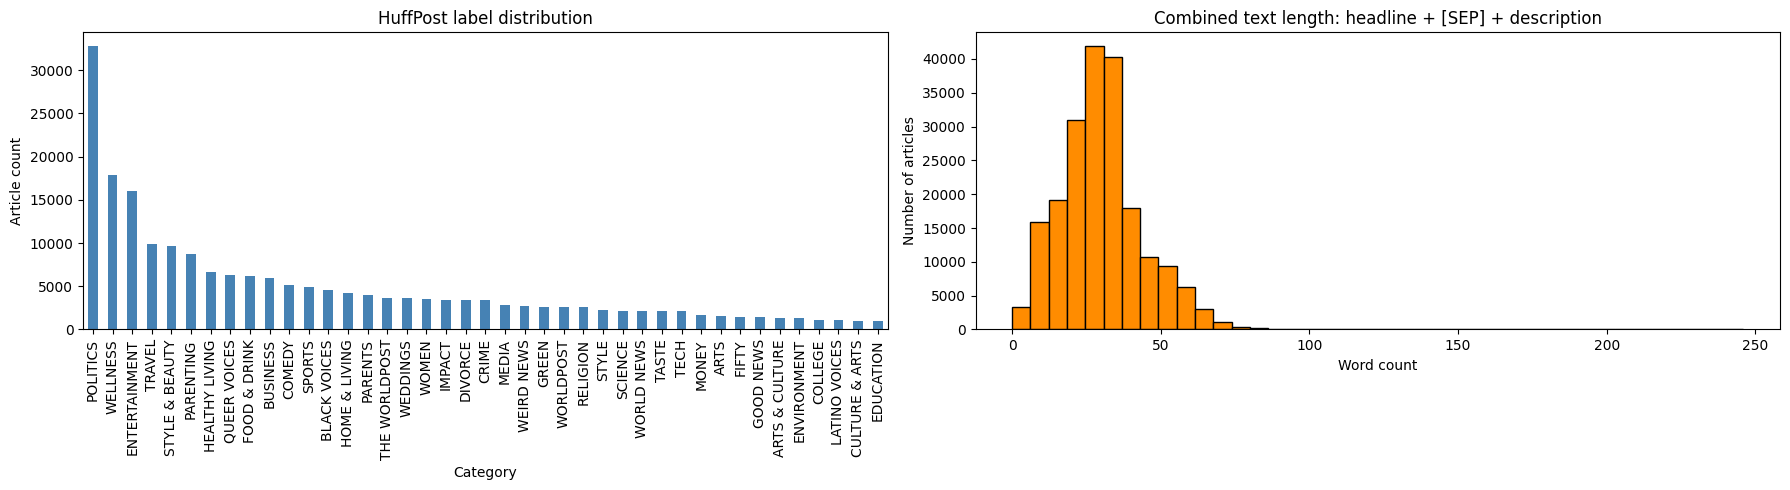

Potentially overlapping labels to watch:
  - WORLD NEWS vs THE WORLDPOST / WORLDPOST
  - WELLNESS vs HEALTHY LIVING
  - STYLE vs STYLE & BEAUTY
  - PARENTS vs PARENTING


In [17]:
# Problem 1 EDA for the chosen dataset: HuffPost News Category
assert 'huff_all' in globals(), "Run the HuffPost loading cell above first."


def build_huffpost_df(dataset):
    df = dataset.to_pandas().copy()

    for col in ["category", "headline", "short_description", "date"]:
        if col in df.columns:
            df[col] = df[col].fillna("").astype(str).str.strip()

    df["text"] = np.where(
        df["short_description"].eq(""),
        df["headline"],
        df["headline"] + " [SEP] " + df["short_description"],
    )
    df["headline_word_count"] = df["headline"].str.split().str.len()
    df["description_word_count"] = df["short_description"].str.split().str.len()
    df["text_word_count"] = df["text"].str.split().str.len()
    return df


huff_df = build_huffpost_df(huff_all)
label_counts = huff_df["category"].value_counts().sort_values(ascending=False)

dataset_summary = pd.Series({
    "rows": len(huff_df),
    "classes": label_counts.size,
    "date_min": huff_df["date"].replace("", np.nan).dropna().min(),
    "date_max": huff_df["date"].replace("", np.nan).dropna().max(),
    "empty_headlines": int(huff_df["headline"].eq("").sum()),
    "empty_short_descriptions": int(huff_df["short_description"].eq("").sum()),
    "duplicate_full_records": int(huff_df.duplicated(subset=["category", "headline", "short_description"]).sum()),
    "duplicate_combined_text": int(huff_df.duplicated(subset=["text"]).sum()),
    "duplicate_headlines": int(huff_df.duplicated(subset=["headline"]).sum()),
    "avg_word_count": round(huff_df["text_word_count"].mean(), 2),
    "median_word_count": int(huff_df["text_word_count"].median()),
})

print("Chosen dataset: HuffPost News Category")
display(dataset_summary.to_frame("value"))

print("Most frequent categories")
display(label_counts.head(10).rename("count").to_frame())

print("Least frequent categories")
display(label_counts.sort_values().head(10).rename("count").to_frame())

print("Random sample records")
display(
    huff_df.sample(5, random_state=random_seed)[["category", "headline", "short_description", "text_word_count"]]
)

print("Examples with empty short descriptions")
display(
    huff_df.loc[huff_df["short_description"].eq(""), ["category", "headline", "short_description"]].head(5)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

label_counts.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("HuffPost label distribution")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Article count")
axes[0].tick_params(axis="x", rotation=90)

axes[1].hist(huff_df["text_word_count"], bins=40, color="darkorange", edgecolor="black")
axes[1].set_title("Combined text length: headline + [SEP] + description")
axes[1].set_xlabel("Word count")
axes[1].set_ylabel("Number of articles")

plt.tight_layout()
plt.show()

ambiguous_pairs = [
    ("WORLD NEWS", "THE WORLDPOST / WORLDPOST"),
    ("WELLNESS", "HEALTHY LIVING"),
    ("STYLE", "STYLE & BEAUTY"),
    ("PARENTS", "PARENTING"),
]
print("Potentially overlapping labels to watch:")
for left, right in ambiguous_pairs:
    print(f"  - {left} vs {right}")


### Graded Questions (2 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **Dataset Summary:**  
   Describe your chosen dataset  (as if explaining to your *clueless boss* what you are working on).
   - State which dataset you are going to use.   
   - What kind of data does it contain (images or text)?  
   - How many samples and classes are there?  
   - What is the task you’ll perform (classification into what categories)?
   - What is the potential business use for this dataset?

1.1. **Answer:** I am choosing the **HuffPost News Category** dataset for the project. It is a multiclass **text classification** problem built from news headlines and short descriptions, which we combine as `headline [SEP] short_description`. The dataset contains **200,853 articles** from **2012-01-28 through 2018-05-26** and **41 topical classes** such as `POLITICS`, `ENTERTAINMENT`, `BUSINESS`, and `TRAVEL`. The task is to predict which topic label each article belongs to. A realistic business use case is **automatic content tagging and routing** for a newsroom, recommendation system, or archive search tool, where fast and consistent categorization reduces manual editorial work.

2. **Initial Observations:**  
   What stood out to you from your EDA?  
   - Did you notice any imbalanced or ambiguous classes?  
   - Any patterns, anomalies, or potential sources of bias?  
   - For images: note any variation in lighting, composition, or color.  
   - For text: mention redundancy, topic overlap, or very short examples.

1.2. **Answer:** The first thing that stood out is that the dataset is **meaningfully imbalanced**: `POLITICS` alone has **32,739** examples, while `EDUCATION` has only **1,004**, and the largest class is about **9.6x the median class size**. I also found **19,712** rows with an empty `short_description`, so some examples are effectively headline-only. There are also small but real data-quality issues, including **470 exact duplicate records** and **488 duplicated combined texts**. On the semantic side, several labels look inherently overlapping, especially `WELLNESS` vs `HEALTHY LIVING`, `STYLE` vs `STYLE & BEAUTY`, and `WORLD NEWS` vs `THE WORLDPOST`/`WORLDPOST`, so I expect some class confusion even with a strong model.

3. **Challenges & Implications:**  
   Based on your inspection, what challenges might affect model performance or training (e.g., imbalance, ambiguous labels, variable quality)?  

1.3. **Answer:** The biggest risks for model performance are **class imbalance**, **label overlap**, and **uneven text quality**. If I optimize only for raw accuracy, the model could over-predict large categories like `POLITICS` and underperform badly on small categories. Ambiguous label boundaries mean some mistakes may reflect the dataset design rather than model weakness. The missing short descriptions and duplicate records also matter: empty descriptions reduce available signal, while duplicates can create leakage if they land in different splits. Finally, text length varies enough that I need to choose a padding/truncation length carefully, although the spread is still manageable for a compact text model.

4. **Preparation Ideas:**  
   What data-cleaning or preprocessing steps might help address these issues?  
   (You will not implement these yet—just describe what you might do later.)

1.4. **Answer:** I would first standardize the input by concatenating `headline` and `short_description` with a separator token, filling missing descriptions with empty strings, and dropping the tiny number of rows where both text fields are blank. Before making train/validation/test splits, I would **deduplicate exact repeats** so the same story cannot leak across splits. Because the dataset is imbalanced, I would use **stratified splits** and probably try **class weights** during training. For modeling, I would start with tokenization, lowercasing handled by the tokenizer, sequence padding to a practical max length, and then compare a simple baseline such as TF-IDF + logistic regression against a neural model with pretrained embeddings or a lightweight transformer.

5. **Reflection:**  
   Why did you choose this dataset over the other one?  
   - What makes it more interesting, realistic, or relevant for you?  
   - What do you expect to learn from working with it?

1.5. **Answer:** I chose HuffPost over Food-101 because it feels like the more interesting and realistic classification problem for this course stage. The text dataset has clear practical value, but it also includes the kinds of messy issues real projects have: imbalance, overlapping labels, duplicates, and partial missing text. It will let me apply the NLP workflow we have already practiced while still making meaningful design choices about tokenization, truncation length, embeddings, and metrics. I expect to learn the most from balancing model simplicity against messy label structure and from evaluating whether a model is actually fair across small and large categories.

## Problem 2 – Frame the Problem (15 pts)

#### Objective

Identify the **key challenges** in your chosen dataset and outline **practical solutions** you would try, plus how you’ll **evaluate** them later.

#### Steps to follow

1. **Diagnose likely challenges (from your EDA):**

   Examples:
   * **Class imbalance:**
     Report label counts and an imbalance ratio (max / median). List any minority classes.
   * **Length/size variance:**
     For text, show length percentiles (50/75/90/95) and estimate truncation rate at candidate `max_text_length`s (e.g., 256/300/512). For images, summarize native resolutions.
   * **Noise/duplicates/leakage:**
     Note empty or malformed items, near-duplicates, and how you would prevent cross-split leakage.
   * **Ambiguous/overlapping labels:**
     Give 2–3 example pairs you expect to be confusable and why.
   * **Compute constraints:**
     Briefly state limits (RAM/GPU/CPU) that might affect batch size, sequence length, or image size.

2. **Map each challenge to a concrete solution plan:**

   Examples:
   * **Imbalance →** `class_weight` or oversampling; report which one you’d try first and why.
   * **Length/size →** pick a target `max_text_length` (e.g., 95th percentile) with masking; for images, standardize resize/crop and basic augmentation.
   * **Noise/duplicates →** dedupe (hash/near-dup), drop empty/very short items, document any relabeling.
   * **Ambiguity →** consider merging labels (if justified), or add features (bigrams/char-ngrams; simple image augmentations).
   * **Overfitting risk →** early stopping on your primary metric, dropout/weight decay, freeze-then-finetune plan (for pretrained features).

3. **Explore appropriate evaluation metrics:**

   Examples:
   * **Primary metric:** pick one aligned to your data (e.g., **macro-F1** if imbalanced; accuracy if balanced).
   * **Secondary metric(s):** per-class precision/recall, confusion matrix.
   * **Protocol:** stratified Train/Val/Test (e.g., 70/15/15), fixed seed, leakage checks.

4. **Answer the graded questions below.**



In [18]:
# Problem 2 framing for HuffPost News Category
assert 'huff_df' in globals() and 'label_counts' in globals(), "Run the Problem 1 EDA cell first."

imbalance_ratio = label_counts.iloc[0] / label_counts.median()
majority_class = label_counts.idxmax()
majority_baseline = label_counts.iloc[0] / len(huff_df)
minority_classes = label_counts.sort_values().head(5)

length_percentiles = huff_df["text_word_count"].quantile([0.50, 0.75, 0.90, 0.95, 0.99]).to_frame("words")
length_percentiles.index = ["p50", "p75", "p90", "p95", "p99"]

candidate_max_lengths = [32, 64, 128, 256]
truncation_table = pd.DataFrame({
    "max_text_length": candidate_max_lengths,
    "share_truncated": [(huff_df["text_word_count"] > n).mean() for n in candidate_max_lengths],
})
truncation_table["share_truncated_pct"] = (100 * truncation_table["share_truncated"]).round(2)

cross_label_headlines = (
    huff_df.loc[huff_df["headline"].ne("")]
    .groupby("headline")["category"]
    .nunique()
)
ambiguous_headline_examples = (
    huff_df[huff_df["headline"].isin(cross_label_headlines[cross_label_headlines > 1].index)]
    .groupby("headline")["category"]
    .apply(lambda s: ", ".join(sorted(set(s))))
    .head(8)
    .to_frame("categories_seen")
)

duplicate_examples = huff_df[
    huff_df.duplicated(subset=["category", "headline", "short_description"], keep=False)
][["category", "headline", "short_description"]].head(6)

challenge_plan = pd.DataFrame([
    {
        "challenge": "Class imbalance",
        "evidence": f"max/median ratio = {imbalance_ratio:.2f}; majority class = {majority_class}",
        "first_fix": "Use stratified splits, macro-F1, and class_weight in the first neural model.",
    },
    {
        "challenge": "Missing or weak descriptions",
        "evidence": f"empty short_description rows = {int(huff_df['short_description'].eq('').sum()):,}",
        "first_fix": "Keep headline-only rows, but flag them and compare performance with/without the description field.",
    },
    {
        "challenge": "Duplicate records / leakage risk",
        "evidence": f"exact duplicate rows = {int(huff_df.duplicated(subset=['category', 'headline', 'short_description']).sum()):,}",
        "first_fix": "Deduplicate before splitting so the same story cannot leak across train/validation/test.",
    },
    {
        "challenge": "Overlapping labels",
        "evidence": "Examples include WELLNESS vs HEALTHY LIVING and WORLD NEWS vs THE WORLDPOST/WORLDPOST.",
        "first_fix": "Use confusion matrices and per-class recall to see which labels are systematically confused.",
    },
    {
        "challenge": "Length / compute tradeoff",
        "evidence": f"p95 length = {int(length_percentiles.loc['p95', 'words'])} words; only {truncation_table.loc[truncation_table['max_text_length'] == 64, 'share_truncated_pct'].iloc[0]:.2f}% exceed 64 tokens.",
        "first_fix": "Start with max_text_length = 64 for efficient baselines; test 128 only if recall appears length-limited.",
    },
])

print(f"Majority-class baseline: always predict '{majority_class}' -> accuracy {majority_baseline:.3f}")
print("Recommended split: stratified 70/15/15 with a fixed random seed after deduplication.")

print("Minority classes")
display(minority_classes.rename("count").to_frame())

print("Length percentiles")
display(length_percentiles)

print("Candidate truncation rates")
display(truncation_table)

print("Challenge -> action plan")
display(challenge_plan)

print("Example duplicated rows")
display(duplicate_examples)

print("Headlines that appear under multiple labels")
display(ambiguous_headline_examples)


Majority-class baseline: always predict 'POLITICS' -> accuracy 0.163
Recommended split: stratified 70/15/15 with a fixed random seed after deduplication.
Minority classes


,count
category,
EDUCATION,1004
CULTURE & ARTS,1030
LATINO VOICES,1129
COLLEGE,1144
ENVIRONMENT,1323


Length percentiles


,words
p50,29.0
p75,36.0
p90,50.0
p95,57.0
p99,68.0


Candidate truncation rates


...

,challenge,evidence,first_fix
0,Class imbalance,max/median ratio = 9.61; majority class = POLI...,"Use stratified splits, macro-F1, and class_wei..."
1,Missing or weak descriptions,"empty short_description rows = 19,712","Keep headline-only rows, but flag them and com..."
2,Duplicate records / leakage risk,exact duplicate rows = 470,Deduplicate before splitting so the same story...
3,Overlapping labels,Examples include WELLNESS vs HEALTHY LIVING an...,Use confusion matrices and per-class recall to...
4,Length / compute tradeoff,p95 length = 57 words; only 1.60% exceed 64 to...,Start with max_text_length = 64 for efficient ...


Example duplicated rows


,category,headline,short_description
8966,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents ..."
9490,PARENTS,The Funniest Tweets From Parents This Week,"Kids may say the darndest things, but parents ..."
10300,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Spencer and Sally Hawkins play 1960s janitors ...
10335,ENTERTAINMENT,"With This 'Shape Of Water' Clip, You'll Fall F...",Spencer and Sally Hawkins play 1960s janitors ...
10363,MEDIA,"From Layoffs To Sexual Assault Allegations, It...","BuzzFeed, ESPN, ""Today"" and more hit new break..."
10371,ARTS & CULTURE,This New York Activist Wants To Replace A Stat...,Glenn Cantave believes white supremacy in 2017...


Headlines that appear under multiple labels


,categories_seen
headline,
6 Ways To Be Happier At Work,"HEALTHY LIVING, WELLNESS"
A Conversation With Decorator and Fashion Designer Kelly Wearstler,"HOME & LIVING, STYLE & BEAUTY"
A Cure for Anxiety,"MONEY, WELLNESS"
A Magical Reunion Between A Girl And Her Very Sentimental Teddy Bear From Dad,"PARENTING, TRAVEL"
A Warning Against A Culture Where Every Child Wins,"PARENTING, WELLNESS"
Agents of Change,"CULTURE & ARTS, PARENTING"
Amazing Grace,"PARENTING, WELLNESS"
America's Best Steakhouses,"FOOD & DRINK, TASTE"


### Graded Questions (3 pts each)

For each question, answer thoroughly but concisely, in a short paragraph, longer or shorter as needed. Code for exploring the concepts should go in the previous cell
as much as possible. 

1. **State the prediction task**  
   - Describe what your model will predict (the *label*).  
   - *Examples:*  
     - “Given a photo of food, predict which of 101 categories it belongs to.”  
     - “Given a news headline + summary, predict its topical category.”  

2.1. **Answer:** The model will take a news headline plus its short description and predict the article’s **topic category**. Concretely, this is a **41-class multiclass classification** task where the output is one label such as `POLITICS`, `ENTERTAINMENT`, `BUSINESS`, `TRAVEL`, or another HuffPost section. In plain language, the model is learning to act like an automatic newsroom tagger.

2. **Define inputs and outputs**  
   - *Inputs:* what information the model receives (e.g., pixel data, tokenized text).  
   - *Outputs:* the categorical label the model will predict.  

2.2. **Answer:** The **input** will be the combined text string `headline [SEP] short_description`, which will then be tokenized and converted into integer sequences for the model. The **output** will be a length-41 probability vector from a softmax layer, where each position corresponds to one HuffPost category and the predicted label is the argmax. For a first deep-learning approach, I would start with a padded sequence length around **64 tokens** and a **100-dimensional GloVe embedding** or another 100-dimensional trainable embedding baseline so the model stays fast enough to iterate on.

3. **Identify possible challenges**  
   - Imbalanced classes, noisy data, ambiguous labels, overlapping features, or missing data  
   - *Images:* variation in lighting, color, composition, or size.  
   - *Text:* class imbalance, duplicate stories, short or ambiguous headlines.  

2.3. **Answer:** The main challenges are measurable from the EDA. First, the label distribution is skewed: the majority class is about **9.6x larger than the median class**, so minority categories are at real risk of low recall. Second, there is noise in the text fields, including **19,712 empty descriptions**, **470 exact duplicate rows**, and **1,509 duplicated headlines**. Third, some categories overlap semantically, such as `WELLNESS` vs `HEALTHY LIVING` and `WORLD NEWS` vs `THE WORLDPOST`/`WORLDPOST`, which means even a good classifier may confuse them. Finally, text length varies, but not enough to justify very long sequences: the **95th percentile is 57 words** and only about **1.6%** of items exceed **64 words**, so the challenge is choosing an efficient cutoff without losing too much signal.

4. **Propose how you will prepare or improve the data to address the challenges**  
   - *Images:* resizing, normalization, data augmentation (flips, rotations, brightness, color jitter).  
   - *Text:* tokenization, stop-word removal, TF-IDF, class balancing, embeddings (choose an embedding approach and specify its vector size). 

2.4. **Answer:** I would prepare the data in four steps. First, clean the text by filling missing descriptions, keeping headline-only rows, and removing exact duplicates before any split. Second, create a **stratified 70/15/15 train/validation/test split** with a fixed seed so every class is represented fairly. Third, tokenize the combined text and start with **max_text_length = 64**, then compare **64 vs 128** only if the confusion matrix suggests that longer articles are being clipped too aggressively. Fourth, train baselines that explicitly address the dataset’s weaknesses: a TF-IDF + logistic regression model for a simple reference point, then a neural model with **100-dimensional embeddings**, `class_weight`, dropout, and early stopping. I would use confusion matrices and per-class recall to decide whether overlapping labels need special handling.

5. **Specify success metrics**  
   - Identify the metrics you plan to use to evaluate model performance—typically **accuracy** and/or **F1-score**, which are standard for classification tasks.  
   - Briefly explain **why** these metrics are appropriate for your dataset and goal. For instance, accuracy may suffice for well-balanced datasets, while F1-score better reflects performance when some classes are under-represented.
   - If your dataset is **imbalanced**, consider computing **per-class metrics** (e.g., precision, recall, or F1 for each label) or **macro-averaged** scores, which give equal weight to each class regardless of its size—ensuring that minority classes are evaluated fairly.
In some cases, weighted averages (which weight classes by their frequency) or **confusion matrices** can also provide useful insight.
> You haven't run any models yet, and we haven’t studied every possible metric, but you’re encouraged to ask your favorite generative AI tool which evaluation metrics might best fit your dataset!
   - Clearly state how you will interpret success—for example, “Our goal is to achieve at least 80% overall accuracy without large per-class disparities.”

2.5. **Answer:** My primary metric will be **macro-F1** because the dataset is imbalanced and I want each category, including small ones, to matter equally in evaluation. I will also report **accuracy** as a secondary metric, since it remains intuitive and easy to explain, but I do not want it to hide poor minority-class performance. In addition, I would inspect **per-class precision/recall/F1** and a **confusion matrix** to see which labels are being confused most often. I would consider the model successful if it performs far above the **16% majority-class baseline**, reaches strong overall accuracy, and avoids collapsing on minority labels; a reasonable early goal would be roughly **70%+ accuracy with macro-F1 above 0.55**.

### Final Question: Describe what use you made of generative AI tools in preparing this Milestone. 

**AI Question: Answer:** I used generative AI as a drafting and coding assistant while preparing this milestone. It helped me organize the EDA steps, write the notebook code cells cleanly, and tighten the wording of the written responses. I still checked the final numbers against the dataset outputs and edited the final answers so they matched the evidence shown in the notebook rather than copying unverified text.

---

## Appendix: A quick guide to Hugging Face Datasets

#### 1) What are they?

* A **table-like** dataset: rows = examples, columns = named fields (e.g., `"image"`, `"label"`, `"headline"`).
* Backed by **Apache Arrow** → fast, memory-efficient, lazy transforms.
* Two core objects:

  * `Dataset` — one table of rows/columns.
  * `DatasetDict` — a dict of splits, e.g. `{"train": Dataset, "val": Dataset, "test": Dataset}`.


#### 2) Load and inspect

```python
from datasets import load_dataset

# Food-101 (images)
food = load_dataset("food101", split="train+validation")  # both splits at once
len(food), food.column_names, food.features
# -> (≈101000, ['image','label'], {'label': ClassLabel(num_classes=101, names=[...])})

# Access by name (not by numeric column index!)
row0 = food[0]
img0, y0 = row0["image"], row0["label"]     # PIL image, int id
label_names = food.features["label"].names
label_names[y0]
```

For text (HuffPost JSON mirror):

```python
url = "https://huggingface.co/datasets/khalidalt/HuffPost/resolve/main/News_Category_Dataset_v2.json"
huff = load_dataset("json", data_files=url, split="train")
huff.column_names  # e.g. ['headline','short_description','category','authors','link','date']
```


#### 3) Common transforms

`Dataset`s are **immutable**: ops return a new dataset.

* **Map** (add/modify columns):

```python
def mk_text(ex):
    h = (ex.get("headline") or "").strip()
    s = (ex.get("short_description") or "").strip()
    return {"text": (h + " [SEP] " + s).strip()}

huff = huff.map(mk_text)  # adds 'text' column
```

* **Class-encode** labels (strings → integers with a vocabulary):

```python
from datasets.features import ClassLabel
if not isinstance(huff.features["category"], ClassLabel):
    huff = huff.class_encode_column("category")  # now ints with .names
```

* **Filter / select / rename / drop**:

```python
small = huff.select(range(5000))  # first 5k rows
huff = huff.remove_columns(["authors","link","date"])
huff = huff.rename_column("category", "label")
```


#### 4) Splitting & shuffling

```python
# Stratified 80/10/10 on Food-101 by 'label'
from datasets import DatasetDict
label_col = "label"

tmp = food.train_test_split(test_size=0.10, seed=42, stratify_by_column=label_col)
train_val = tmp["train"].train_test_split(test_size=1/9, seed=42, stratify_by_column=label_col)
ds = DatasetDict(train=train_val["train"], val=train_val["test"], test=tmp["test"])

len(ds["train"]), len(ds["val"]), len(ds["test"])
```

* `train_test_split` is **random by default** (reproducible with `seed=`).
* You typically **don’t need to pre-shuffle** datasets if your training dataloader already shuffles each epoch.


#### 5) Working with images

Use `with_transform` to apply on-the-fly resizing/augmentation and return tensors:

```python
import torchvision.transforms as T
from torch.utils.data import DataLoader
import torch, math, random

IM_SIZE = 224
train_tfms = T.Compose([T.RandomResizedCrop(IM_SIZE), T.RandomHorizontalFlip(), T.ToTensor()])
eval_tfms  = T.Compose([T.Resize(256), T.CenterCrop(IM_SIZE), T.ToTensor()])

def add_pixel_values(ex, tfms):  # ex['image'] -> ex['pixel_values']
    ex = dict(ex); ex["pixel_values"] = tfms(ex["image"]); return ex

train_t = ds["train"].with_transform(lambda ex: add_pixel_values(ex, train_tfms))
val_t   = ds["val"].with_transform(lambda ex: add_pixel_values(ex, eval_tfms))

def collate(batch):
    return {"pixel_values": torch.stack([b["pixel_values"] for b in batch]),
            "labels": torch.tensor([b["label"] for b in batch])}

train_loader = DataLoader(train_t, batch_size=64, shuffle=True,  collate_fn=collate)
val_loader   = DataLoader(val_t,   batch_size=64, shuffle=False, collate_fn=collate)
```

### 6) Working with Text

You can preprocess and tokenize text datasets using either a **transformer tokenizer** or a **linguistic pipeline like spaCy**, depending on your model type and goals.


#### Option A: Transformer Tokenizer (for fine-tuning models like BERT or DistilBERT)

Use a pretrained tokenizer with the Hugging Face `map` method to efficiently process your dataset in batches:

```python
from transformers import AutoTokenizer

tok = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def tokenize(batch):
    return tok(batch["text"], truncation=True, padding="max_length", max_length=128)

tokenized = huff.map(
    tokenize,
    batched=True,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

This produces token IDs, attention masks, and other fields expected by transformer models.
Use this approach if your project involves fine-tuning pretrained language models.


#### Option B: spaCy Tokenization and Cleaning (for classical ML or custom preprocessing)

If you are **not using transformers**, or if you want to explore feature engineering (e.g., TF-IDF, word frequency, or embedding averages), you can preprocess text with **spaCy** instead.

```python
# !pip install spacy
# !python -m spacy download en_core_web_sm

import spacy
from datasets import load_dataset

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "textcat"])
STOP = spacy.lang.en.stop_words.STOP_WORDS

def spacy_clean(batch):
    docs = list(nlp.pipe(batch["text"], batch_size=1000))
    cleaned = []
    for doc in docs:
        tokens = [t.lemma_.lower() for t in doc if t.is_alpha and not t.is_stop]
        cleaned.append(" ".join(tokens))
    return {"text_clean": cleaned, "len_tokens": [len(c.split()) for c in cleaned]}

huff = huff.map(
    spacy_clean,
    batched=True,
    batch_size=1000,
    remove_columns=[c for c in huff.column_names if c not in ("category", "label")]
)
```

The resulting column `text_clean` can be used with:

* `TfidfVectorizer` (Scikit-learn)
* `TextVectorization` (Keras)
* or any other custom embedding method.

> 💡 **Tip:** spaCy is ideal for lightweight NLP pipelines or for models that rely on explicit preprocessing (lemmatization, stopword removal). Transformer tokenizers, by contrast, expect *raw text* and handle subword tokenization internally.



#### 7) Slicing, concatenating, saving

```python
# Slicing
head_1000 = food.select(range(1000))
tail_10pct = food.select(range(int(0.9*len(food)), len(food)))

# Concatenate splits/datasets
from datasets import concatenate_datasets
all_train = concatenate_datasets([ds["train"], ds["val"]])

# Save / reload
ds.save_to_disk("food101_splits")
from datasets import load_from_disk
ds2 = load_from_disk("food101_splits")
```


#### 8) Quick “gotchas”

* **Columns by name** (strings), not numeric indices.
* Avoid converting huge columns to `list(...)` unless necessary; prefer vectorized ops with `map`, `filter`, `select`.
* `PYTHONHASHSEED` must be set **before** the Python process starts to matter; use explicit `seed=` arguments for reproducibility.
* Datasets print **previews** (e.g., `Column([6, 6, 6, ...])` is just the first few values).


#### 9) A minimal checklist to follow

1. `load_dataset(...)` → confirm `column_names`, `features`.
2. Build any needed columns (`"text"`), and **class-encode** labels if strings.
3. Make a **stratified 80/10/10** split (`train_test_split` ×2).
4. Do **EDA**: class counts, sample printouts or image grids.
5. For training:

   * **images** → `with_transform` + DataLoader
   * **text** → tokenizer via `.map(...)` + trainer/model pipeline
6. Save your `DatasetDict` with `save_to_disk(...)` (optional for text but handy, **don't** use it for big image datasets).

